# Decusuib Trees

In a decision tree, we decide if a node will be split or not by looking at the information gain that the split would give us.
$$ \text{Information Gain} = H(p_{1}^{node}) - (w^{left}H(p_{1}^{left}) + w^{right}H(p_{1}^{right}) $$
where $H$ is the entropy, defined as:
$$ H(p_{1}) = -p_{1}log_{2}(p_{1}) - (1 - p_{1}) log_{2}(1-p_{1}) $$
<br>
Note that the H attains its higher value when $ p = 0.5 $, means that the probability of event is 0.5. Minimum value attained when $ p = 0 $ and $p = 1$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *

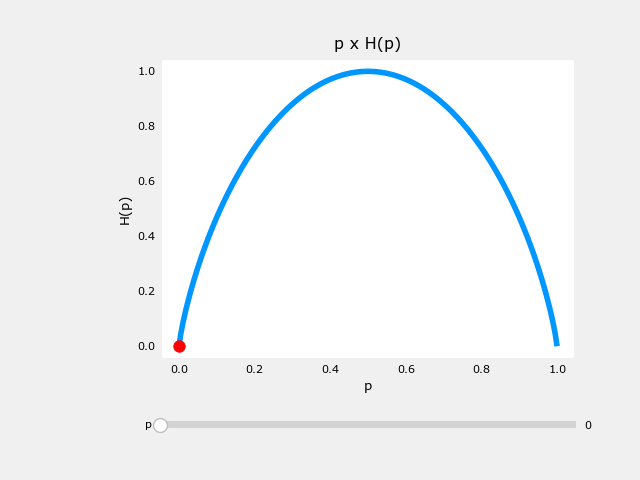

In [2]:
%matplotlib widget
_ = plot_entropy()

we will use one-hot encoding to encode the categorical features. They will be as follows:
- Ear shape: pointy = 1, floppy = 0
- Face shape: Round = 1, Not Round = 0
- Whiskers: Present = 1, Absent = 0

- X_train: for each example, contains 3 features
- y_train: whether the animal is a cat

In [3]:
X_train = np.array([[1, 1, 1],
[0, 0, 1],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 1],
 [1, 1, 0],
 [0, 0, 0],
 [1, 1, 0],
 [0, 1, 0],
 [0, 1, 0]])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [4]:
#For instance, the first example
X_train[0]

array([1, 1, 1])

Now let's write a function to compute the entropy


In [5]:
def entropy(p):
    if p == 0 or p == 1:
        return 0
    else:
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

print(entropy(0.5))

1.0


In [6]:
def split_indices(X, index_feature):
    """Given a dataset and a index feature, return two lists for the two split nodes, the left node has the animals that have 
    that feature = 1 and the right node those that have the feature = 0 
    index feature = 0 => ear shape
    index feature = 1 => face shape
    index feature = 2 => whiskers
    """
    left_node = []
    right_node = []
    for i, x in enumerate(X):
        if x[index_feature] == 1:
            left_node.append(i)
        else:
            right_node.append(i)

    return left_node, right_node

In [7]:
split_indices(X_train, 0)

([0, 3, 4, 5, 7], [1, 2, 6, 8, 9])

In [10]:
def weighted_entropy(X,y,left_indices,right_indices):
    """
    This function takes the splitted dataset, the indices we chose to split and returns the weighted entropy.
    """
    w_left = len(left_indices) / len(X)
    w_right = len(right_indices) / len(X)
    p_left = sum(y[left_indices]) / len(left_indices)
    p_right = sum(y[right_indices]) / len(right_indices)

    weighted_entropy = w_left * entropy(p_left) + w_right * entropy(p_right)
    return weighted_entropy

In [11]:
left_indices, right_indices = split_indices(X_train, 0)
weighted_entropy(X_train, y_train, left_indices, right_indices)

np.float64(0.7219280948873623)

In [12]:
def information_gain(X, y, left_indices, right_indices):
    """
    Here, X has the elements in the node and y is theirs respectives classes
    """
    p_node = sum(y) / len(y)
    h_node = entropy(p_node)
    w_entropy = weighted_entropy(X, y, left_indices, right_indices)
    return h_node - w_entropy

In [13]:
information_gain(X_train, y_train, left_indices, right_indices)

np.float64(0.2780719051126377)

Now compute the information gain if we split the root node for each feature

In [14]:
for i, feature_name in enumerate(['Ear Shape', 'Face Shape', 'Whiskers']):
    left_indices, right_indices = split_indices(X_train, i)
    i_gain = information_gain(X_train, y_train, left_indices, right_indices)
    print(f"Feature: {feature_name}, information gain if we split the root node using this feature: {i_gain:.2f}")

Feature: Ear Shape, information gain if we split the root node using this feature: 0.28
Feature: Face Shape, information gain if we split the root node using this feature: 0.03
Feature: Whiskers, information gain if we split the root node using this feature: 0.12


In [15]:
tree = []
build_tree_recursive(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], "Root", max_depth=1, current_depth=0, tree = tree)

generate_tree_viz([0,1,2,3,4,5,6,7,8,9], y_train, tree)

 Depth 0, Root: Split on feature: 0
 - Left leaf node with indices [0, 3, 4, 5, 7]
 - Right leaf node with indices [1, 2, 6, 8, 9]


FileNotFoundError: [Errno 2] No such file or directory: 'images/0.png'